# River Flow Forecasting with Data Assimilation (DA): Latent Embedding Data Assimilation Visualizations & Sweep Evaluation

This notebook evaluates **Data Assimilation on Latent Embedding Vectors** (`embedded_dynamics`, `embedded_statics`, or `both`) in `MeanEmbeddingForecastLSTM`.

### Standardized 6-Stage Evaluation Protocol:
1. **Data Ingestion & Benchmark Initialization**: Ingest experiment-specific parquets (strictly isolated), detect horizons ($t+0 \dots t+7$), and extract Caravans V2 physical attributes.
2. **Top-N Configuration Benchmark Matrix**: Operational leaderboard with bold champions per leadtime and blue/red delta shading.
3. **Hyperparameter Influence & Main Effects Grid**: Non-parametric rank contribution (%) and marginal response curves annotated with catchment win rates (%).
4. **Cumulative Distribution Functions (CDFs) & Memory Decay**: Dual-panel CDF suite (Panel A: Fixed Lead 1 Day comparing all sweep configurations; Panel B: Multi-horizon progression comparing key reference models) + persistence decay.
5. **Basin Physical Characteristics Efficacy**: Unified 2x3 horizontal diverging effect-size bar grid (numbers cleanly positioned above whiskers) and master characteristics table.
6. **Linked Interactive Dashboard**: Dynamic Catchment Info Card, interactive Bokeh map with country boundaries and TapTool point-clicking, and continuous hydrographs with KGE & NSE in the legend.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

# Add repository root and tutorial utils to sys.path
cwd = Path(os.getcwd()).resolve()
repo_root = next(
    (p for p in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent, Path('/usr/local/google/home/kruparell/openhydronets_next')] if (p / 'tutorial' / 'utils').is_dir()),
    cwd
)
tut_utils = repo_root / 'tutorial' / 'utils'
if str(tut_utils) not in sys.path:
    sys.path.insert(0, str(tut_utils))

from da_eval import DAAnalysisSession
print("DA Evaluation environment loaded successfully.")

DA Evaluation environment loaded successfully.


## Stage 1: Data Ingestion & Benchmark Initialization

In this section, we initialize the evaluation session. The engine automatically:
1. Scopes data loading strictly to this experiment's directory (preventing cross-contamination).
2. **Optional In-Distribution / Overlap Filtering**: Supports filtering evaluation catchments to just the overlapping training/pretrained basins (`filter_basins=...`), filtering out unseen out-of-distribution global catchments.
3. Detects available forecast horizons (including dynamic **$t+0$ nowcast** detection).
4. Synthesizes the **Per-Basin Best DA** oracle upper bound.
5. Extracts physical morphology, slope, elevation, snow fraction, and aridity from `Caravans_V2/attributes.zarr`.

In [ ]:
# Curated Experiment Selection Registry
EXPERIMENTS = {
    # 0000. Stage 53: 4,287-Basin 6-Year (2017-01-01 .. 2023-09-30) 84-Config S / S+H / S+H+F Factorial Suite [XID 294056488]
    #       filtered_basins_nse_gt_0.5.txt (all 4,287 catchments), CMAL mixture_mean, NSE loss,
    #       bg=0.5, tol=0.05, epochs=50, 4 shards/config (85 configs x 4 shards = 340 V100 Borg jobs).
    #       - S (Static-only, 12 cfgs):      w in {7, 14, 30, 90} x lr in {0.001, 0.005, 0.1}
    #       - S+H (Hindcast+Static, 36 cfgs): w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #       - S+H+F (Triple, 36 cfgs):       w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #       AR(1) benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "294056488": {
        "name": "da_st53_4287b_6yr_s_sh_shf_84cfg_20260928",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st53_4287b_6yr_s_sh_shf_84cfg_20260928",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st53_4287b_6yr_s_sh_shf_84cfg_20260928",
    },
    # 000. Stage 52: 1,000-Basin 1-Year (2017) 84-Config S / S+H / S+H+F Factorial Suite [XID 293997545]
    #      stratified_1000_screen.txt basins (n=672 finite across all 7 leads), CMAL mixture_mean, NSE loss,
    #      bg=0.5, tol=0.05, epochs=50, 1 shard/config (85 V100 jobs = 1 baseline + 84 DA configs).
    #      - S (Static-only, 12 cfgs):      w in {7, 14, 30, 90} x lr in {0.001, 0.005, 0.1}
    #      - S+H (Hindcast+Static, 36 cfgs): w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #      - S+H+F (Triple, 36 cfgs):       w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #      AR(1) benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "293997545": {
        "name": "da_st52_1000b_1yr_s_sh_shf_84cfg_20260928",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st52_1000b_1yr_s_sh_shf_84cfg_20260928",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st52_1000b_1yr_s_sh_shf_84cfg_20260928",
    },
    # 00. Stage 50: 4,287-Basin 6-Year (2017-01-01 .. 2023-09-30) Winners Benchmark [XID 293022110]
    #     11 global DA winners (4 Hindcast+Static, 2 Dual, 2 Triple, 2 Hindcast-Only, 1 Static-Only)
    #     + E_baseline_0da across all 4,287 filtered catchments (filtered_basins_nse_gt_0.5.txt),
    #     CMAL mixture_mean point estimates, 12 configs x 8 shards = 96 V100 Borg jobs.
    #     AR(1) benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "293022110": {
        "name": "da_st50_4287b_6yr_winners_20260924",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st50_4287b_6yr_winners_20260924",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st50_4287b_6yr_winners_20260924",
    },
    # 01. Stage 51: 500-Basin 2-Year (2017-2018) 72-Config Hindcast(+Static) LR-Ratio / Tol / BG Sweep [XID 293040723]
    #     stratified_500_screen.txt basins, CMAL mixture_mean, NSE loss, 1 shard/config (73 V100 jobs).
    #     Config IDs: S51<group>_w<w>_lrd<lr_dyn>_r<lr_stat/lr_dyn>_bg<bg>_tol<tol>_ep<epochs>
    #     (r0 = hindcast-only; r>0 = hindcast + static with lr_stat = r * lr_dyn).
    #     - S51A (29): ratio sweep r in {0, 0.1, 0.3, 1}, w in {7, 14, 30, 90}, lr_dyn in {0.005, 0.01}, bg 0.5
    #     - S51B (12): heavy regularization bg in {1, 2, 5} at lr_dyn 0.1, r 0.1, w in {7, 14, 30, 90}
    #     - S51C (22): early-stopping tol in {0.01, 0.05, 0.1} x epochs in {25, 50}
    #     - S51E (5):  extreme LR / bg probes at w in {30, 90};  S51F (4): w = 365 long-window probes
    #     AR(1) benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "293040723": {
        "name": "da_st51_500b_l47_hs_ratio_tol_bg_20260925",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st51_500b_l47_hs_ratio_tol_bg_20260925",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st51_500b_l47_hs_ratio_tol_bg_20260925",
    },
    # 0. Stage 49: 4,287-Basin 2-Year (2017-2018) Full 20-Config Global Winners Benchmark [XID 292697766]
    #    Evaluates 19 global DA winners across all 5 categories (Hindcast+Static, Triple, Dual,
    #    Hindcast-Only, Static-Only) + E_baseline_0da evaluated across all 4,287 global catchments
    #    under CMAL mixture_mean point estimates (100 V100 Borg jobs).
    "292697766": {
        "name": "da_st49_4287b_winners_suite_2yr_20260924",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st49_4287b_winners_suite_2yr_20260924",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st49_4287b_winners_suite_2yr_20260924",
    },
    # 0a. Stage 48: 500-Basin 2-Year (2017-2018) 72-Config Tier 1 Coupled Hindcast+Static Sweep [XID 292693312]
    #    Evaluates 72 hindcast_static coupled DA configs (loss_w = w in {7, 14, 30, 90},
    #    lr in {0.1, 0.01, 0.001}, bg in {0.0, 0.05, 0.5}, tol in {None, 0.05}, epochs=50)
    #    + E_baseline_0da evaluated under CMAL mixture_mean point estimates.
    "292693312": {
        "name": "da_st48_500b_hs_coupled_mixture_mean_20260924",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st48_500b_hs_coupled_mixture_mean_20260924",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st48_500b_hs_coupled_mixture_mean_20260924",
    },
    # 0b. Stage 45: 2,000-Basin 2-Year (2017-2018) 10-Config Winners Benchmark [XID 292499199]
    #    Evaluates 9 top Embedding DA winners (Hindcast + Static W2B/S45_HS and Hindcast-Only W2/S45_H
    #    across w in {14, 30, 60}, loss in {NSE, MSE}, lw in {5, 10, 60}) + E_baseline_0da across
    #    2,000 stratified basins (10 shards/cfg = 100 V100 Borg jobs).
    "292499199": {
        "name": "da_embeddings_st45_2000b_2yr_winners_20260923",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_embeddings_st45_2000b_2yr_winners_20260923",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_embeddings_st45_2000b_2yr_winners_20260923",
    },
    # 0c. Stage 41: 20-Basin 55-Config Unscaled Regularization & Loss (CMAL vs NSE) Factorial V100 Sweep [XID 292328989]
    #    Evaluates 54 DA configurations + E_baseline_0da across 20 stratified screening basins:
    #    - 3 Embedding Targets x Windows: Static (S_w180), Triple/All (T_w90), Dual-Dynamic (D_w30)
    #    - 2 Optimization Losses: CMAL (probabilistic NLL) vs NSE (variance-normalized L2)
    #    - 3 Learning Rates: lr in {0.1, 0.01, 0.001}
    #    - 3 Unscaled Background Regularization Weights: bg in {0, 0.001, 0.1}
    #    - Fixed epochs=80, early_stopping_min_loss=0.01 (tol0.01).
    "292328989": {
        "name": "da_st41_unscaled_20b_20260923",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st41_unscaled_20b_20260923",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st41_unscaled_20b_20260923",
    },
    # 0d. Stage 37: 500-Basin 50-Config Exploratory Log-Grid Factorial V100 Sweep [XID 291959952]
    #    Decouples learning rate from background weight across orders of magnitude.
    #    Group A (12): Static w=90 full 3x3 (lr_stat in {0.01,0.05,0.20} x bg_stat in {0.0,0.2,5.0})
    #                  + w=180 spine (lr in {0.02,0.10,0.25} at bg=0.2).
    #    Group B (20): Dual-dyn full 3x3 at w=14 and w=30 (lr_dyn in {0.02,0.10,0.25}
    #                  x bg_dyn in {0.01,0.5,10.0}) + 2 ceiling probes at w=30 (lr=0.40).
    #    Group C (12): Triple, 4 regime corners (unleashed / freeDyn_anchStat /
    #                  anchDyn_freeStat / stiffHighLR) x w in {7, 30, 90}.
    #    Group E (6):  Tolerance + config ablations against Stage 36 winners.
    #    All at epochs=50 (unaffected by the learning_rate_epoch_drop decay issue).
    "291959952": {
        "name": "da_st37_500b_50cfg_factorial_v100_20260922",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st37_500b_50cfg_factorial_v100_20260922",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st37_500b_50cfg_factorial_v100_20260922",
    },
    # 0e. Stage 36: 500-Basin 12-Config Hydrological Regimes V100 Sweep [XID 291944723]
    #    Evaluates 12 regime configs (BF1-3 Static, FL1-3 Flashy Dual-Dyn w/ boosted LR,
    #    TM1-3 Temperate Heavy-Prior Dual-Dyn, ALL1-3 Triple) + E_baseline_0da across 500 basins.
    "291944723": {
        "name": "da_st36_500b_12cfg_regimes_v100_20260922",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st36_500b_12cfg_regimes_v100_20260922",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st36_500b_12cfg_regimes_v100_20260922",
    },
    # 0f. Unified 5-Model Benchmark: Open Baseline vs Embedding DA vs MF2LSTM (Cases 1, 2, 3) [XID 291570224]
    #     100 benchmark basins (2017-2018), native tester.py CSVs + consolidated test_results*.zarr stores.
    "291570224": {
        "name": "mf2lstm_vs_da_benchmark_100b_20260921",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/mf2lstm_vs_da_benchmark_100b_20260921",
        "local_dir": "/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/mf2lstm_vs_da_benchmark_100b_20260921",
    },
}

# Select active run XID:
# - '294056488': Stage 53 4,287-Basin 6-Year (2017-01 .. 2023-09) 84-Config S / S+H / S+H+F Factorial Suite (mixture_mean)
# - '293997545': Stage 52 1,000-Basin 1-Year (2017) 84-Config S / S+H / S+H+F Factorial Suite (mixture_mean)
# - '293022110': Stage 50 4,287-Basin 6-Year (2017-01 .. 2023-09) 12-Config Winners Benchmark (mixture_mean)
# - '293040723': Stage 51 500-Basin 2-Year (2017-2018) 72-Config LR-Ratio / Tol / BG Sweep (mixture_mean)
# - '292697766': Stage 49 4,287-Basin 2-Year (2017-2018) Full 20-Config Global Winners Benchmark (mixture_mean)
# - '292693312': Stage 48 500-Basin 2-Year (2017-2018) 72-Config Coupled Hindcast+Static Sweep (mixture_mean)
# - '292499199': Stage 45 2,000-Basin 2-Year (2017-2018) 10-Config Winners Benchmark (CSV + Zarr staged)
# - '292328989': Stage 41 20-Basin 55-Config Unscaled Regularization & Loss (CMAL vs NSE) Factorial Sweep
# - '291959952': Stage 37 500-Basin 50-Config Exploratory Log-Grid Factorial Sweep (2017, q_0.5 median reduction)
# - '291944723': Stage 36 500-Basin 12-Config Hydrological Regimes V100 Sweep (2017, q_0.5 median reduction)
# - '291570224': Unified 5-Model Benchmark (Open Baseline vs Embedding DA vs MF2LSTM Cases 1, 2, 3)

ACTIVE_RUN_ID = "293022110"

selected_exp = EXPERIMENTS[ACTIVE_RUN_ID]
DATA_DIR = selected_exp["local_dir"]
CNS_DIR = selected_exp["cns_dir"]
MODE = selected_exp["mode"]
ATTR_ZARR = "/usr/local/google/home/kruparell/Caravans_V2/attributes.zarr"

# Sync Toggle: Set True to pull new shards from CNS; False for ultra-fast local loading once staged.
SYNC_FROM_CNS = False

# Basin filtering: Filter strictly to overlapping pretrained/training catchments
FILTER_BASINS_PATH = "/usr/local/google/home/kruparell/openhydronets_next/example-configs/filtered_basins_nse_gt_0.5.txt"
FILTER_TO_OVERLAPPING = False  # Set to False to analyze all evaluated catchments

# Report how many configs are actually staged locally (auto-syncs from CNS if 0 staged locally).
from pathlib import Path as _Path
_staged_csvs = list(_Path(DATA_DIR).glob("**/test_metrics*.csv"))
_staged_zarrs = list(_Path(DATA_DIR).glob("**/test_results*.zarr"))
_staged_parquets = list(_Path(DATA_DIR).glob("*.parquet"))
print(f"Loading Experiment XID {ACTIVE_RUN_ID} ({selected_exp['name']}) [Mode: {MODE}]...")
print(f"Locally staged files: {len(_staged_csvs)} metric CSVs, {len(_staged_zarrs)} Zarr stores, {len(_staged_parquets)} parquets")

# AR(1) benchmark rows (fixed rho + per-basin best rho) are synthesised from the staged Baseline zarr the
# first time an experiment is loaded (~20 s per 1k basins-years; skipped when the CSVs already exist).
if _staged_zarrs:
    from da_eval.ar1_metrics import build_ar1_metrics
    build_ar1_metrics(DATA_DIR)

SELECTION = dict(metric="NSE Skill Score", leads=(4,5,6,7), agg="mean", global_stat="median")

session = DAAnalysisSession(
    selection=SELECTION,
    mode=MODE,
    data_dir=DATA_DIR,
    attr_zarr_path=ATTR_ZARR,
    cns_dir=CNS_DIR if (SYNC_FROM_CNS or (not _staged_csvs and not _staged_parquets)) else None,
    filter_basins=FILTER_BASINS_PATH if FILTER_TO_OVERLAPPING else None,
    load_timeseries=False,  # Fast loading for full 4,287-basin metrics (~8s)
)

Loading Experiment XID 294056488 (da_st53_4287b_6yr_s_sh_shf_84cfg_20260928) [Mode: embedding]...
Locally staged files: 4 metric CSVs, 0 Zarr stores, 0 parquets
Initializing DA Analysis Session (Mode: EMBEDDING)...
[INFO] No parquet files found for evaluation metrics. Attempting legacy CSV ingestion from /usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st53_4287b_6yr_s_sh_shf_84cfg_20260928...
[LEGACY CSV] Ingested 0 evaluation metrics across 0 configs.
[WARNING] No evaluation parquet files loaded from '/usr/local/google/home/kruparell/openhydronets_next/tutorial/data/eval_staging/da_st53_4287b_6yr_s_sh_shf_84cfg_20260928'.


### Reference models (set once for the whole notebook)

`SELECTION` in the cell above defines **Global-Best DA**, **Per-Basin DA**, **Global-Best AR(1)** and **Per-Basin AR(1)** for every later stage. No plot or table chooses its own reference models, and the same Global-Best config is shown at every lead time. Plot titles and legends state the rule (e.g. *selected on median NSE skill score, t+1*).

> [!NOTE]
> Selection is **in-sample**: models are chosen on the same period they are evaluated on. Per-Basin models are therefore oracle upper bounds, and the Global-Best is optimistic by a (small) selection bias.


In [3]:
# Display units: NSE skill score shown as a percentage in every plot / table (SS_NSE x 100 = % reduction in
# squared error vs the open-loop). Presentation only - thresholds, colour limits and arguments stay fractions
# (e.g. vmin=-0.2 -> -20%, bin_thresholds "0.01, 0.05" -> 1% / 5%). Set False for raw fractions.
session.set_ss_percent(True)

# Ranking behind the selection (DA and AR(1) pools, winner = bold) and each config's share of Per-Basin wins.
session.selection_summary()


AttributeError: 'DAAnalysisSession' object has no attribute 'selection'

## Stage 2: Top-N Configuration Benchmark Matrix

Evaluates multi-leadtime forecasting skill across horizons ($t+0 \dots t+7$, auto-detected).
* **Bolding**: Independent winning configuration highlighted in bold for each individual lead horizon column.
* **Color Shading**: Colorblind-friendly soft **Blue** for positive skill gains ($\Delta > 0$), soft **Red** for degradation ($\Delta < 0$).

In [ ]:
# Paper summary table: Baseline open-loop NSE (first row) + NSE skill score (SS_NSE) of each reference scheme
# per lead window. Per basin: mean over the window's leads; then the median across the common basins.
# Global / Per-Basin rows follow the notebook-wide SELECTION (Stage 1). Raw numbers: session.horizon_table
session.show_horizon_summary_table(
    windows={"Short-Range (Days 1–3)": (1, 2, 3),
             "Medium-Range (Days 4–7)": (4, 5, 6, 7),
             "Full Horizon (Days 1–7)": (1, 2, 3, 4, 5, 6, 7)},
    stat="median",
    baseline_in_header=True,   # open-loop NSE under each column heading (False = separate Baseline row)
    # percent follows session.set_ss_percent (Stage 1); pass percent=True/False to override for this table
    # labels={"global_rho": "Global AR(1) Post-Processing (SS<sub>NSE</sub>)"},   # optional row renames
)


,Short-Range (Days 1–3)NSEbase = –,Medium-Range (Days 4–7)NSEbase = –,Full Horizon (Days 1–7)NSEbase = –
Assimilation Scheme — SSNSE (%),,,


,Short-Range (Days 1–3)NSEbase = –,Medium-Range (Days 4–7)NSEbase = –,Full Horizon (Days 1–7)NSEbase = –
Assimilation Scheme — SSNSE (%),,,


In [ ]:
# Top-N Configuration Leaderboard across all forecast horizons (increase top_n=80 to view full grid)
session.show_top_n_table(top_n=15)

,Configuration,Window,LR,Epochs,BG Reg,Loss,Target,NSE (t+1),SS_NSE (t+1),% SS<-0.01 (t+1),NSE (t+2),SS_NSE (t+2),% SS<-0.01 (t+2),NSE (t+3),SS_NSE (t+3),% SS<-0.01 (t+3),NSE (t+4),SS_NSE (t+4),% SS<-0.01 (t+4),NSE (t+5),SS_NSE (t+5),% SS<-0.01 (t+5),NSE (t+6),SS_NSE (t+6),% SS<-0.01 (t+6),NSE (t+7),SS_NSE (t+7),% SS<-0.01 (t+7),SS_NSE (mean t+1..t+7),% SS<-0.01 (mean t+1..t+7)
0,Baseline (Open-Loop),-,-,-,-,-,Baseline,0.639,+0.000,0.0%,0.612,+0.000,0.0%,0.599,+0.000,0.0%,0.562,+0.000,0.0%,0.548,+0.000,0.0%,0.524,+0.000,0.0%,0.461,+0.000,0.0%,+0.000,0.0%
1,Global-Best DA (S52_HS_w14_lrd0.005_r0.3_bg0.5_tol0.05_ep50),14,0.005000,50,0.500000,-,Both Embeddings,0.717,+0.187,15.6%,0.651,+0.061,21.6%,0.622,+0.047,22.4%,0.587,+0.031,25.0%,0.558,+0.020,29.8%,0.537,+0.013,29.9%,0.463,+0.010,27.4%,+0.053,24.5%
2,Global-Best Rho (AR1_postprocess_rho0.65),-,-,-,-,-,AR1 Post-process,0.738,+0.226,23.7%,0.643,+0.039,37.5%,0.620,+0.026,31.7%,0.573,+0.014,23.1%,0.556,+0.009,15.3%,0.528,+0.008,5.5%,0.466,+0.004,1.3%,+0.047,19.7%
3,Per-Basin DA,-,-,-,-,-,Tuned Per Basin,0.727,+0.182,15.0%,0.670,+0.083,15.0%,0.649,+0.071,12.1%,0.610,+0.081,6.4%,0.588,+0.072,4.9%,0.562,+0.066,5.3%,0.508,+0.055,5.0%,+0.087,9.1%
4,Per-Basin Rho (AR1_Per_Basin_Best_Rho),-,-,-,-,-,AR1 Per-Basin Rho,0.733,+0.171,18.3%,0.646,+0.014,21.8%,0.634,+0.016,10.8%,0.592,+0.011,1.6%,0.565,+0.009,0.7%,0.540,+0.007,0.3%,0.473,+0.002,0.7%,+0.033,7.8%
5,S52_T_w30_lrd0.005_r0.3_bg0.5_tol0.05_ep50,30,0.005000,50,0.500000,-,All Embeddings,0.726,+0.211,18.3%,0.653,+0.065,24.6%,0.625,+0.047,23.3%,0.586,+0.030,25.3%,0.557,+0.019,29.2%,0.540,+0.016,30.1%,0.465,+0.010,30.7%,+0.057,25.9%
6,S52_T_w30_lrd0.005_r1_bg0.5_tol0.05_ep50,30,0.005000,50,0.500000,-,All Embeddings,0.726,+0.210,18.2%,0.653,+0.066,25.5%,0.628,+0.044,27.6%,0.585,+0.030,31.4%,0.551,+0.014,35.1%,0.531,+0.013,34.8%,0.462,+0.012,34.8%,+0.056,29.6%
7,S52_T_w14_lrd0.005_r0.3_bg0.5_tol0.05_ep50,14,0.005000,50,0.500000,-,All Embeddings,0.729,+0.210,18.8%,0.653,+0.059,22.1%,0.623,+0.044,22.5%,0.585,+0.032,26.4%,0.557,+0.017,29.5%,0.536,+0.015,28.9%,0.463,+0.010,28.0%,+0.055,25.2%
8,S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50,90,0.005000,50,0.500000,-,All Embeddings,0.730,+0.214,18.0%,0.657,+0.073,27.0%,0.620,+0.040,27.7%,0.586,+0.027,30.5%,0.550,+0.012,37.9%,0.536,+0.008,35.4%,0.465,+0.006,38.2%,+0.054,30.7%
9,S52_HS_w30_lrd0.005_r0.3_bg0.5_tol0.05_ep50,30,0.005000,50,0.500000,-,Both Embeddings,0.719,+0.190,15.0%,0.651,+0.063,23.0%,0.622,+0.048,23.7%,0.587,+0.031,24.4%,0.556,+0.020,30.2%,0.539,+0.014,30.4%,0.464,+0.012,29.6%,+0.054,25.2%


,Configuration,Window,LR,Epochs,BG Reg,Loss,Target,NSE (t+1),SS_NSE (t+1),% SS<-0.01 (t+1),NSE (t+2),SS_NSE (t+2),% SS<-0.01 (t+2),NSE (t+3),SS_NSE (t+3),% SS<-0.01 (t+3),NSE (t+4),SS_NSE (t+4),% SS<-0.01 (t+4),NSE (t+5),SS_NSE (t+5),% SS<-0.01 (t+5),NSE (t+6),SS_NSE (t+6),% SS<-0.01 (t+6),NSE (t+7),SS_NSE (t+7),% SS<-0.01 (t+7),SS_NSE (mean t+1..t+7),% SS<-0.01 (mean t+1..t+7)
0,Baseline (Open-Loop),-,-,-,-,-,Baseline,0.639,+0.000,0.0%,0.612,+0.000,0.0%,0.599,+0.000,0.0%,0.562,+0.000,0.0%,0.548,+0.000,0.0%,0.524,+0.000,0.0%,0.461,+0.000,0.0%,+0.000,0.0%
1,Global-Best DA (S52_HS_w14_lrd0.005_r0.3_bg0.5_tol0.05_ep50),14,0.005000,50,0.500000,-,Both Embeddings,0.717,+0.187,15.6%,0.651,+0.061,21.6%,0.622,+0.047,22.4%,0.587,+0.031,25.0%,0.558,+0.020,29.8%,0.537,+0.013,29.9%,0.463,+0.010,27.4%,+0.053,24.5%
2,Global-Best Rho (AR1_postprocess_rho0.65),-,-,-,-,-,AR1 Post-process,0.738,+0.226,23.7%,0.643,+0.039,37.5%,0.620,+0.026,31.7%,0.573,+0.014,23.1%,0.556,+0.009,15.3%,0.528,+0.008,5.5%,0.466,+0.004,1.3%,+0.047,19.7%
3,Per-Basin DA,-,-,-,-,-,Tuned Per Basin,0.727,+0.182,15.0%,0.670,+0.083,15.0%,0.649,+0.071,12.1%,0.610,+0.081,6.4%,0.588,+0.072,4.9%,0.562,+0.066,5.3%,0.508,+0.055,5.0%,+0.087,9.1%
4,Per-Basin Rho (AR1_Per_Basin_Best_Rho),-,-,-,-,-,AR1 Per-Basin Rho,0.733,+0.171,18.3%,0.646,+0.014,21.8%,0.634,+0.016,10.8%,0.592,+0.011,1.6%,0.565,+0.009,0.7%,0.540,+0.007,0.3%,0.473,+0.002,0.7%,+0.033,7.8%
5,S52_T_w30_lrd0.005_r0.3_bg0.5_tol0.05_ep50,30,0.005000,50,0.500000,-,All Embeddings,0.726,+0.211,18.3%,0.653,+0.065,24.6%,0.625,+0.047,23.3%,0.586,+0.030,25.3%,0.557,+0.019,29.2%,0.540,+0.016,30.1%,0.465,+0.010,30.7%,+0.057,25.9%
6,S52_T_w30_lrd0.005_r1_bg0.5_tol0.05_ep50,30,0.005000,50,0.500000,-,All Embeddings,0.726,+0.210,18.2%,0.653,+0.066,25.5%,0.628,+0.044,27.6%,0.585,+0.030,31.4%,0.551,+0.014,35.1%,0.531,+0.013,34.8%,0.462,+0.012,34.8%,+0.056,29.6%
7,S52_T_w14_lrd0.005_r0.3_bg0.5_tol0.05_ep50,14,0.005000,50,0.500000,-,All Embeddings,0.729,+0.210,18.8%,0.653,+0.059,22.1%,0.623,+0.044,22.5%,0.585,+0.032,26.4%,0.557,+0.017,29.5%,0.536,+0.015,28.9%,0.463,+0.010,28.0%,+0.055,25.2%
8,S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50,90,0.005000,50,0.500000,-,All Embeddings,0.730,+0.214,18.0%,0.657,+0.073,27.0%,0.620,+0.040,27.7%,0.586,+0.027,30.5%,0.550,+0.012,37.9%,0.536,+0.008,35.4%,0.465,+0.006,38.2%,+0.054,30.7%
9,S52_HS_w30_lrd0.005_r0.3_bg0.5_tol0.05_ep50,30,0.005000,50,0.500000,-,Both Embeddings,0.719,+0.190,15.0%,0.651,+0.063,23.0%,0.622,+0.048,23.7%,0.587,+0.031,24.4%,0.556,+0.020,30.2%,0.539,+0.014,30.4%,0.464,+0.012,29.6%,+0.054,25.2%


## Stage 3: Optimal Configuration Allocation (Globally Best vs. Per-Basin DA)

* **Panel A (Horizontal Bar Chart)**: Top $N$ configurations ranked by the number of catchments ($N_{\text{basins}}$) where they achieve optimal performance, highlighting the **Globally Best DA Configuration** ($\star$).
* **Panel B (Market Share Donut Chart)**: Visualizes catchment win share ($\%$) across top models vs. the remaining sweep configurations.
* **Optimal Allocation Matrix**: Summary table reporting per-basin win counts, win share ($\%$) and global median $\Delta\text{NSE}$.

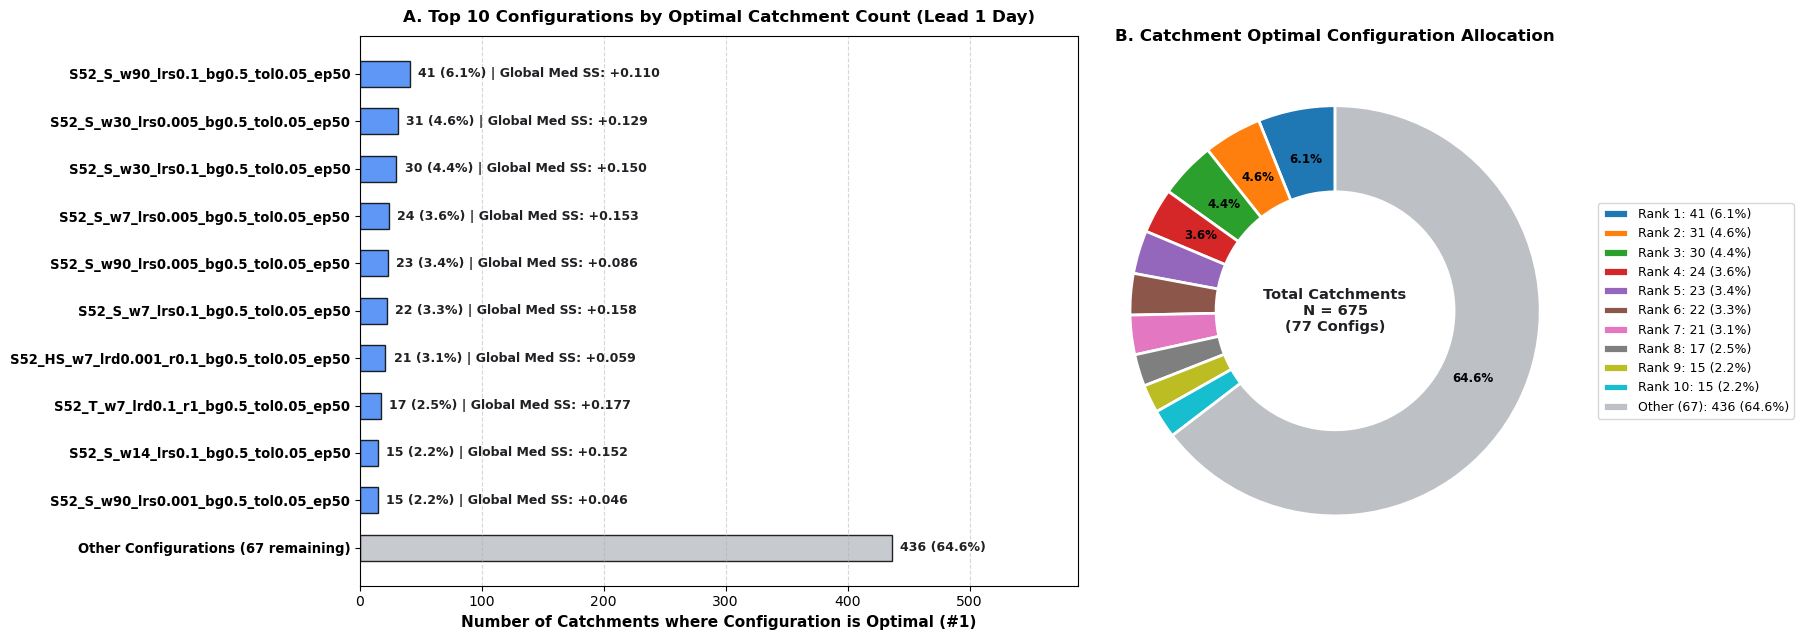

,Rank,Config ID,Is Global Best,Basins Won,Win Share (%),Cumulative Basins,Cumulative Share (%),Global Med SS_NSE,Global Med NSE,Global Rank,Window,LR,Epochs,BG Reg,Target
0,1,S52_S_w90_lrs0.1_bg0.5_tol0.05_ep50,False,41,6.1%,41,6.1%,+0.110,0.692,75,90,0.100000,50,0.500000,Static Embeddings
1,2,S52_S_w30_lrs0.005_bg0.5_tol0.05_ep50,False,31,4.6%,72,10.7%,+0.129,0.692,67,30,0.005000,50,0.500000,Static Embeddings
2,3,S52_S_w30_lrs0.1_bg0.5_tol0.05_ep50,False,30,4.4%,102,15.1%,+0.150,0.704,58,30,0.100000,50,0.500000,Static Embeddings
3,4,S52_S_w7_lrs0.005_bg0.5_tol0.05_ep50,False,24,3.6%,126,18.7%,+0.153,0.712,56,7,0.005000,50,0.500000,Static Embeddings
4,5,S52_S_w90_lrs0.005_bg0.5_tol0.05_ep50,False,23,3.4%,149,22.1%,+0.086,0.681,82,90,0.005000,50,0.500000,Static Embeddings
5,6,S52_S_w7_lrs0.1_bg0.5_tol0.05_ep50,False,22,3.3%,171,25.3%,+0.158,0.716,55,7,0.100000,50,0.500000,Static Embeddings
6,7,S52_HS_w7_lrd0.001_r0.1_bg0.5_tol0.05_ep50,False,21,3.1%,192,28.4%,+0.059,0.661,91,7,0.001000,50,0.500000,Both Embeddings
7,8,S52_T_w7_lrd0.1_r1_bg0.5_tol0.05_ep50,False,17,2.5%,209,31.0%,+0.177,0.719,47,7,0.100000,50,0.500000,All Embeddings
8,9,S52_S_w14_lrs0.1_bg0.5_tol0.05_ep50,False,15,2.2%,224,33.2%,+0.152,0.715,57,14,0.100000,50,0.500000,Static Embeddings
9,10,S52_S_w90_lrs0.001_bg0.5_tol0.05_ep50,False,15,2.2%,239,35.4%,+0.046,0.661,92,90,0.001000,50,0.500000,Static Embeddings


In [ ]:
# 1. Top-N Configurations by Optimal Basin Count (Bar Chart + Market Share Donut)
# Winners = the Per-Basin DA picks of the notebook-wide SELECTION; lead_time only sets the displayed medians.
session.plot_optimal_basin_distribution(top_n=10, lead_time=1, plot_type="combined")

# 2. Optimal Basin Allocation Summary Table
session.show_optimal_basin_distribution_table(top_n=10, lead_time=1)

## Stage 4: Hyperparameter Influence, Risk Profiles & Downside Tail Analysis

* **Interactive Risk & Distribution Suite**: Interactively stratify the entire hyperparameter space by **Learning Rate (LR)**, **Background Weight (bg)**, **Assimilation Window (w)**, or **Early Stopping Tolerance (tol)**.
* **Downside Tail Metric ($Q_{0.05}$)**: Directly identifies safe vs. risky parameter regimes by measuring the 5th percentile ($Q_{0.05}$ downside drop), severe degradation rate ($\text{SS} < -0.10$), safe configuration percentage, and upside potential ($Q_{0.75}, Q_{0.95}$).
* **Marginal Influence Plot**: Also supports running the ANOVA rank decomposition and marginal response curves.

In [ ]:
# Interactive Hyperparameter Risk Profile & Downside Tail Analysis
# Toggle between Learning Rate, BG Regularization, Window, and Tolerance
# to inspect downside degradation (Q0.05), severe degradation rates, and win rates
session.show_hyperparameter_risk_suite(default_group="Learning Rate", default_lead=1)

Output()

In [ ]:
# Optional: Classical ANOVA Rank Contribution (%) & Marginal Main Effects Curves
# session.plot_hyperparameter_effects(lead_time=1)

In [ ]:
# Static Paper Figure (Figure 1c): Learning Rate as a Conservativeness / Tail-Safety Dial
# Two risk-return panels on the NSE skill score (per basin, mean over the lead window):
#   (a) Days 1-3  |  (b) Days 4-7   -- one shared legend below (colour = Learning Rate, shape = LR Ratio).
# Reference models (Global-Best / Per-Basin DA) follow the notebook-wide SELECTION (Stage 1), in both panels.
# If Per-Basin DA falls outside a panel's view it is pinned to the edge with an arrow; its true coordinates
# are written in a box in that panel's emptiest corner.
import matplotlib.pyplot as plt
from da_eval import risk_return as rr

LEAD_WINDOWS = {"(a) Days 1–3": (1, 2, 3), "(b) Days 4–7": (4, 5, 6, 7)}
panels = []
for name, leads in LEAD_WINDOWS.items():
    tbl, info = session.get_risk_return_table(leads=leads, metric="skill", agg="mean")
    panels.append((tbl, info, f"{name} (N = {info['n_basins']})"))

fig_rr = rr.plot_risk_return_panels(
    panels,
    figsize=(17, 7.2),
    risk_stat="q10", return_stat="median",
    color_by="Learning Rate", marker_by="LR Ratio",   # swap marker_by="Target" for S / S+H / S+H+F shapes
    label_by=None, label_frontier=0,                  # no in-plot text
    show_refs=("baseline", "global_da"),
    inset_refs=("per_basin_da",),                     # off-scale callout instead of stretching the axes
)
fig_rr.set_dpi(160)
plt.show()

# Pareto-optimal configurations per lead window (sorted by 50th-percentile skill)
for (tbl, info, title) in panels:
    print(title)
    display(rr.style_frontier_table(rr.frontier_table(tbl, risk_stat="q10", return_stat="median"), metric="skill"))


### Stage 4b: Risk–Return (Pareto) View of DA Configurations

One point per DA configuration. For each basin, the score is the chosen metric averaged (or summed) over **any set of lead times** you toggle, e.g. t+7 only, t+4–7, or t+1,3,7. Only basins where every selected lead is finite for every config are used. Across those basins:

* **Y (return)**: typical gain (median by default; mean, Q25 or % improved also available).
* **X (risk)**: downside (10th percentile by default; Q05, CVaR over the worst 10%, or % harmed also available). Right/up is better.
* **Colour / marker / label by** any hyperparameter that varies in the run. **Hold fixed** picks a controlled slice; everything else stays as the grey cloud.
* The red dashed line is the **Pareto frontier** (non-dominated configs), listed in the table below the plot. Reference points show Baseline, Global-Best DA, Per-Basin DA and the AR(1) post-processors.
* **Basins** restricts the plot to one Köppen-Geiger climate group.

In [ ]:
# Interactive risk–return suite. Everything is also available as arguments for static paper figures, e.g.:
#   session.plot_risk_return(leads=(4, 5, 6, 7), metric="delta", agg="sum", risk_stat="q10", return_stat="median",
#                            color_by="Learning Rate", marker_by="Window (Days)",
#                            fixed={"LR Ratio": 0.1, "BG Weight": 0.5, "Tolerance": "0.05", "Epochs": 50})
# which returns the Pareto-frontier table. session.get_risk_return_table(...) returns (per-config table, info).
session.plot_risk_return(
    leads=(4, 5, 6, 7),
    metric="skill",          # "skill" | "delta" | "nse"
    agg="mean",              # "mean" | "sum" over the selected leads
    risk_stat="q10",         # median | mean | q05 | q10 | q25 | cvar10 | pct_improved | pct_harm
    return_stat="median",
    color_by="Learning Rate",
    marker_by="Window (Days)",
    interactive=True,
)

Output()

## Stage 5: Cumulative Distribution Functions (CDFs) & Leadtime Memory Decay

* **Interactive Single-Cell Metric Toggle**: Switch seamlessly between **Per-Gauge $\Delta\text{NSE}$**, **NSE Skill Score ($\text{SS}_{\text{NSE}} = 1 - \frac{1 - \text{NSE}_{\text{DA}}}{1 - \text{NSE}_{\text{Base}}}$)**, **Per-Gauge $\Delta\text{KGE}$**, **Absolute $\text{NSE}$**, and **Absolute $\text{KGE}$** across forecast horizons (`t+1` to `t+7`).
* **Dual-Panel CDF Suite**:
  * **Panel A (Fixed Horizon)**: Per-gauge ECDF across all evaluated configurations vs. Open-Loop Baseline ($\Delta = 0$ / $\text{SS} = 0$), **Global Best DA**, and **Per-Basin Best DA (Oracle)** with median gain and gauge win-rate (%) annotations.
  * **Panel B (Multi-Horizon Progression)**: ECDF progression from short-range (`t+1`) to medium-range (`t+7`) forecasts.
* **Memory Persistence & Skill Decay Curve**: Tracks median performance (or median $\Delta$ / skill score gain) and `[25th, 75th]` IQR across all lead times.

In [ ]:
# Single-Cell Interactive CDF & Horizon Decay Suite
# Toggle between:
#   - "skill_nse": Per-Gauge NSE Skill Score [1 - (1 - DA NSE) / (1 - Base NSE)] (Default)
#   - "delta_nse": Per-Gauge ΔNSE (DA - Baseline)
#   - "delta_kge": Per-Gauge ΔKGE (DA - Baseline)
#   - "NSE":       Absolute NSE
#   - "KGE":       Absolute KGE
# Models row: toggle Global-Best DA / Per-Basin DA / Global-Best AR(1) / Per-Basin AR(1) (post-processing) and
# the grey sweep curves. `show=` sets the starting selection, e.g.
#   show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"]
# (Set interactive=False to render static figures directly, e.g. session.plot_ecdfs(metric="skill_nse", interactive=False))
session.plot_ecdfs(metric="skill_nse", lead_time=1, interactive=True, show_decay=True,
                   show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"])

Output()

### Stage 5c: Publication Figures — Absolute Skill, Decay & Harm

These are the figures intended for the paper. Every panel uses **one common gauge set** (gauges with a valid score for every model at every lead) and the same reference models:
* **Global-Best DA / Per-Basin DA / Global-Best AR(1) / Per-Basin AR(1)**: as defined once by `SELECTION` in Stage 1 (one config for all leads; Per-Basin models are oracles).

The figures are:
* **Main (a) CDFs at t+1 / t+3 / t+7, in absolute NSE.** These include the **Baseline** (dashed) and a naive **Persistence** forecast $q(T{+}L)=q_{obs}(T)$ (dotted). They show that the Baseline is skilful in its own right and how much DA adds on top.
* **Main (b) Skill decay.** Median + IQR of NSE per lead. The lower panel shows the % of gauges *harmed* relative to the Baseline (SS < −0.01 solid, SS < −0.05 dashed).
* **Main (c) Harm/benefit bars.** Share of gauges in each skill-score category per lead, using the same 5 bins as the maps.
* **Supplement:** CDFs for the remaining leads, skill-score CDFs for all leads, and skill-score violins.

> A skill score is relative to the Baseline (Baseline ≡ 0), so it cannot show the Baseline's own skill. Absolute NSE is used for skill, and skill score only for *harm/benefit*.

=== Main text ===
[LAZY TS] Loaded cached index: 1 stores, 1 configs, 1,000 basins.


/usr/local/google/home/kruparell/openhydronets_next/tutorial/utils/da_eval/paper_figures.py:136: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(o_m, axis=0)
/usr/local/google/home/kruparell/openhydronets_next/tutorial/utils/da_eval/paper_figures.py:136: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(o_m, axis=0)
/usr/local/google/home/kruparell/openhydronets_next/tutorial/utils/da_eval/paper_figures.py:136: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(o_m, axis=0)
/usr/local/google/home/kruparell/openhydronets_next/tutorial/utils/da_eval/paper_figures.py:136: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(o_m, axis=0)
/usr/local/google/home/kruparell/openhydronets_next/tutorial/utils/da_eval/paper_figures.py:136: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(o_m, axis=0)
/usr/local/google/home/kruparell/openhydronets_next/tutorial/utils/da_eval/paper_figures.py:136: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(o_m, axis=0)
/usr

Persistence: q(T+L) = q_obs(T) | Baseline: open-loop model | Global-Best DA: S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50 | Per-Basin DA: best DA per gauge (median NSE skill score at t+1) | Global-Best AR(1): AR1_postprocess_rho0.65


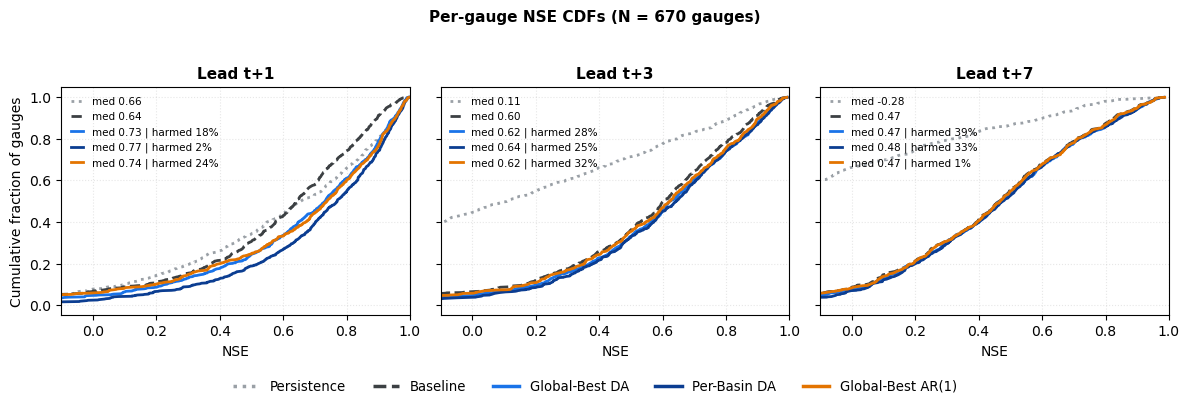

Persistence: q(T+L) = q_obs(T) | Baseline: open-loop model | Global-Best DA: S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50 | Per-Basin DA: best DA per gauge (median NSE skill score at t+1) | Global-Best AR(1): AR1_postprocess_rho0.65


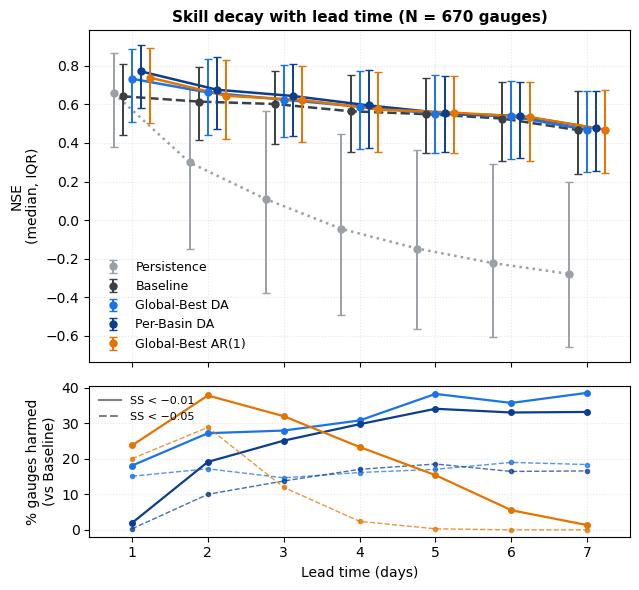

Global-Best DA: S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50 | Per-Basin DA: best DA per gauge (median NSE skill score at t+1) | Global-Best AR(1): AR1_postprocess_rho0.65


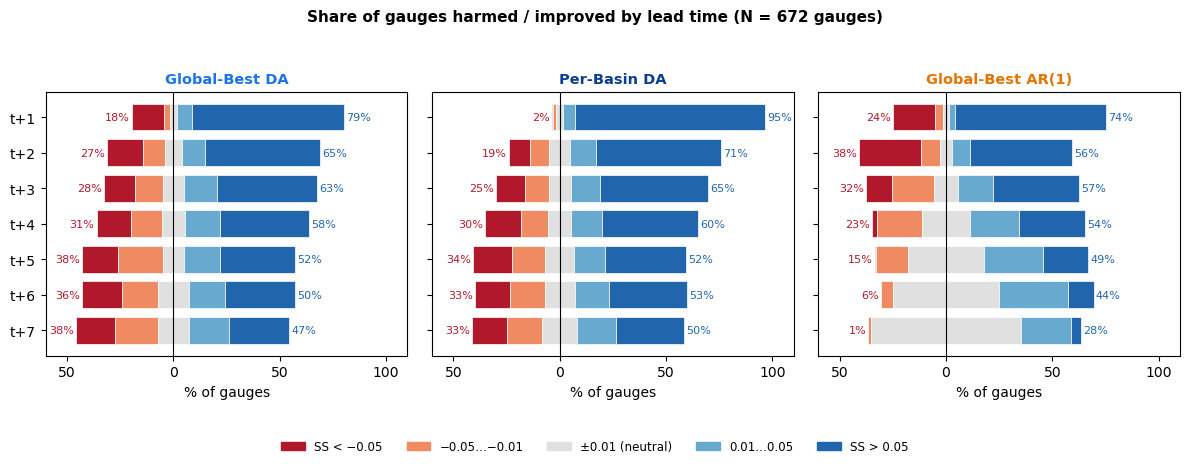

=== Supplement ===
Persistence: q(T+L) = q_obs(T) | Baseline: open-loop model | Global-Best DA: S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50 | Per-Basin DA: best DA per gauge (median NSE skill score at t+1) | Global-Best AR(1): AR1_postprocess_rho0.65


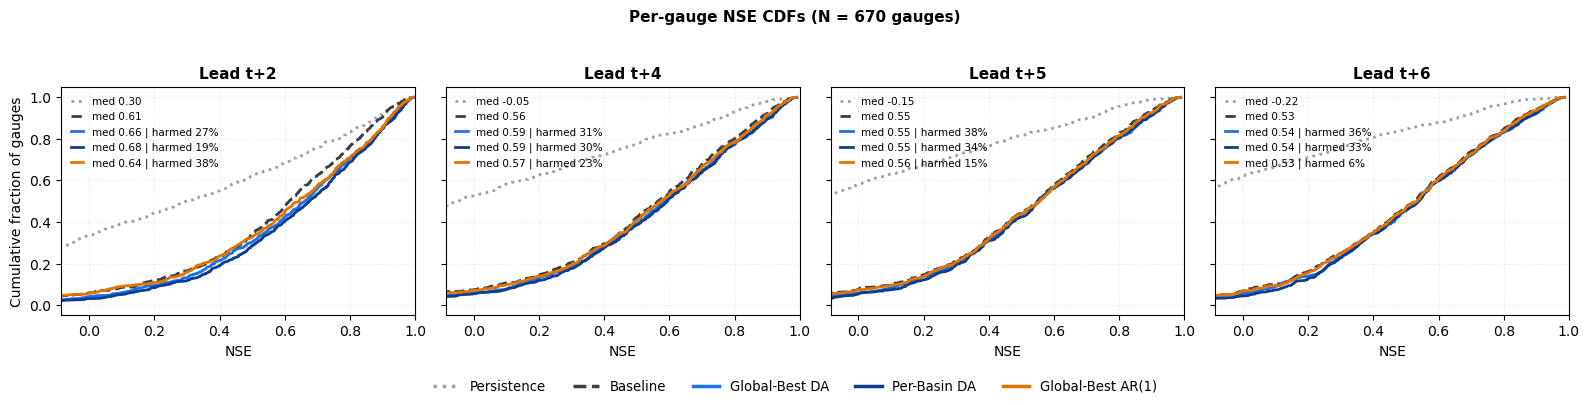

Global-Best DA: S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50 | Per-Basin DA: best DA per gauge (median NSE skill score at t+1) | Global-Best AR(1): AR1_postprocess_rho0.65


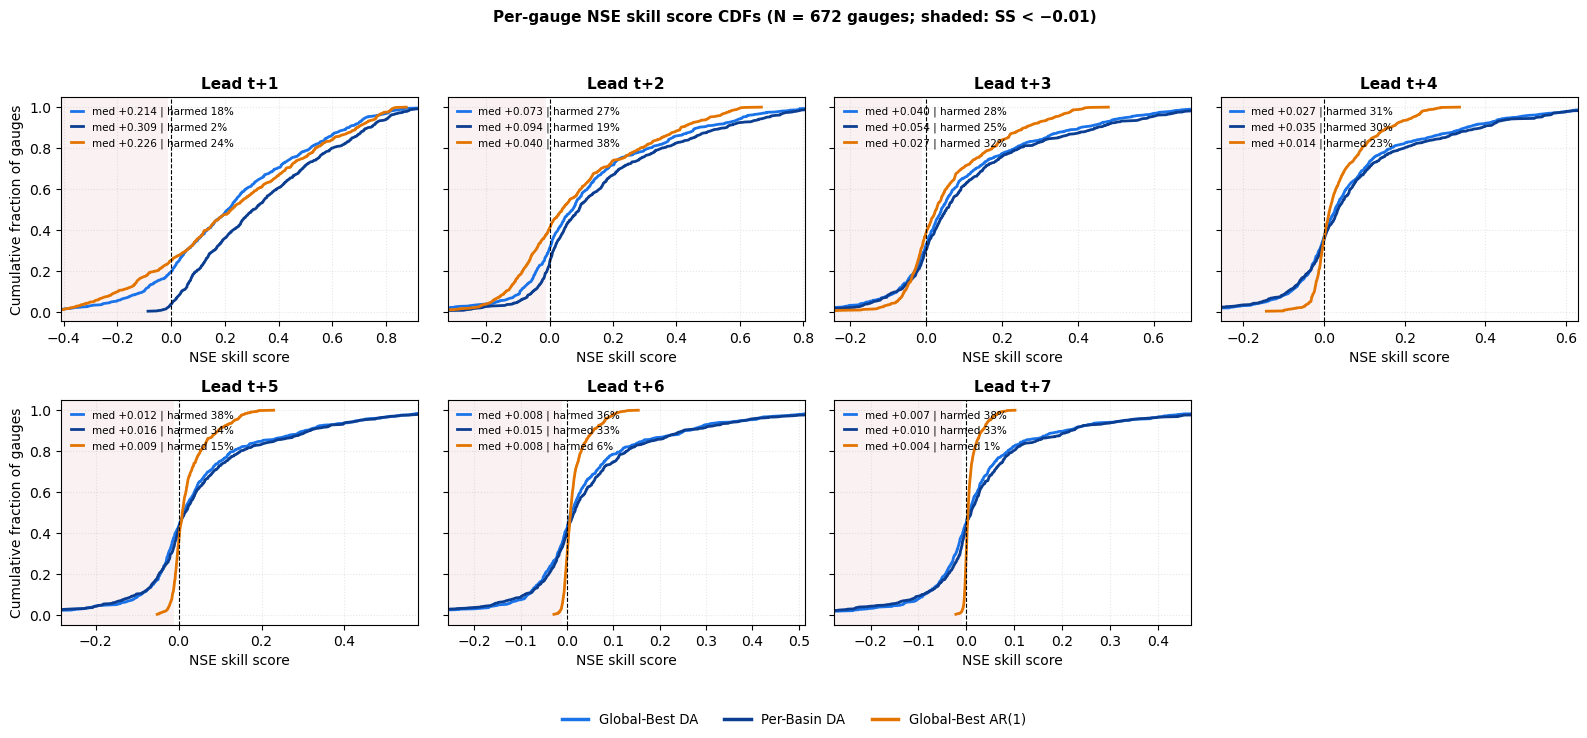

Global-Best DA: S52_T_w90_lrd0.005_r1_bg0.5_tol0.05_ep50 | Per-Basin DA: best DA per gauge (median NSE skill score at t+1) | Global-Best AR(1): AR1_postprocess_rho0.65


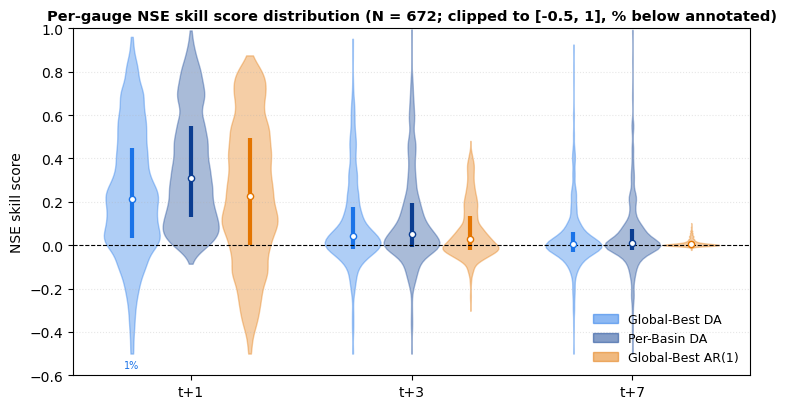

In [ ]:
# Publication figures (main text + supplement) in one call.
#   metric: "NSE" (absolute, default; shows Baseline & Persistence), "KGE" (absolute; no Persistence), or "SS" (skill score)
#   models: any of "Global-Best DA", "Per-Basin DA", "Global-Best AR(1)", "Per-Basin AR(1)"
PAPER_MODELS = ["Global-Best DA", "Per-Basin DA", "Global-Best AR(1)"]
session.show_paper_skill_figures(main_leads=(1, 3, 7), supplement=True, metric="NSE", models=PAPER_MODELS)

# Individual figures (e.g. to save at publication resolution):
# fig = session.plot_skill_cdf_panels(leads=(1, 3, 7), metric="NSE", models=PAPER_MODELS)
# fig = session.plot_skill_decay(metric="NSE", models=PAPER_MODELS, harm_thresholds=(0.01, 0.05))
# fig = session.plot_harm_benefit_bars(models=PAPER_MODELS, bin_thresholds=(0.01, 0.05))
# fig = session.plot_skill_violins(leads=(1, 3, 7), metric="SS", models=PAPER_MODELS)
# fig.savefig("fig_skill_cdfs.pdf", bbox_inches="tight")

### Stage 5b: Stratified Catchment CDFs & Basin-Type Leaderboards (Morphological Filtering)

Test the hypothesis that **different configurations are optimal for different catchment types** (e.g. Arid vs Humid, Poor vs Strong Baseline, Low vs High Precipitation):
* **Live Interactive Attribute Filtering**: Filter catchments by:
  * **Baseline Quality Tier**: `Base NSE` range (e.g. Low `< 0.50`, Mid `0.50–0.70`, High `≥ 0.70`).
  * **Aridity Regimes**: UNEP Aridity Index ($P / \text{PET}$) range (e.g. Arid `< 0.50`, Sub-Humid `0.50–0.80`, Humid `≥ 0.80`).
  * **Precipitation Regimes**: Mean annual precipitation range (e.g. Low `< 1.5`, Moderate `1.5–3.5`, High `> 3.5` mm/day).
  * **Drainage Area & Snow Fraction**: Area in km² or cryosphere snow-melt fraction.
* **Stratified Sub-Cohort Leaderboard Scorecard**: Automatically ranks all sweep configurations on the filtered catchment cohort, highlighting the **winning configuration** (🥇) for that specific basin type along with win rates and degradation rates.
* **Dual-Panel Stratified ECDF & Decay Curve**:
  * **Panel A**: Empirical CDF comparing the candidate configurations specifically on the filtered catchments.
  * **Panel B**: Lead time memory persistence decay trajectory ($t+1$ to $t+7$) for the top configs on this stratum.

In [ ]:
# Launch Interactive Stratified Catchment ECDF & Leaderboard Suite
# Adjust the Preset dropdown or drag the range sliders to test different basin types in real time.
# Supported metrics: "skill_nse", "delta_nse", "delta_kge", "NSE", "KGE"
session.plot_stratified_cdfs(lead_time=1, metric="skill_nse", interactive=True)

Output()

## Stage 6: Basin Physical Characteristics Efficacy (6 Dimensions)

Macro-level effect-size analysis examining where Data Assimilation provides maximum benefit:
1. **Aridity Index ($P/\text{PET}$)**
2. **Baseline Performance Tier (Base NSE)**
3. **Flow Regime Seasonality**
4. **Catchment Drainage Area ($\text{km}^2$)**
5. **Snow Fraction**
6. **Terrain Slope (degrees)**

In [ ]:
# Interactive 6-Dimension Physical Catchment Characteristics Suite
# Toggle Plot View ("both", "global_best", "per_basin_best", "none") and Table View ("global_best", "per_basin_best", "both", "none")
session.plot_basin_characteristics_efficacy(
    config="both",
    default_table="global_best",
    interactive=True,
)

Output()

### Stage 6b: Configuration–Catchment Affinity (Static-Attribute PCA & Clustering)

Stage 6 asks whether DA *helps* differently by basin type. Stage 6b asks whether the *best DA configuration* differs by basin type, i.e. whether a basin's static attributes tell us which config to deploy.

**Method**
1. **Feature space**: the 84 `static_attributes` the foundation model sees (read-only from the pretrained `config.yml`), log1p on heavy-tailed attributes, median-imputed, z-scored, then **PCA** keeping 90% of variance.
2. **Target**: per basin, the NSE Skill Score of every real DA config (AR(1) post-processing and baseline rows excluded), averaged over the chosen leads. From this we derive the **regret vector** $r_c = SS_{best} - SS_c$, the hard winner, and **confident winners** (winner − runner-up gap ≥ 0.02).
3. **Clustering**: K-Means (or GMM) in PC space; k chosen by silhouette (or BIC).
4. **Tests**:
   - **Association**: Cramér's V between cluster and (confident) winner, and between cluster and the best level of each hyperparameter axis, with permutation p-values.
   - **Policy value (decisive)**: out-of-fold under *spatially grouped* CV, compare *Global Best*, *Cluster Best*, *kNN Best*, *Predicted Best* (gradient-boosted regret regressors) and the per-basin *Oracle*. The headline is **% of the Global→Oracle gap recovered**. A *shuffled-attributes* control should sit at ≈0% or below.

> [!NOTE]
> Most per-basin "wins" are near-ties. A significant association (low p) with **~0% gap recovered** means that attribute structure exists, but it is too weak to beat simply deploying the Global Best everywhere.

**How to read the Policy Ladder**: ≥30% recovered = real structure (deploy per cluster); 10–30% = partial (select only the associated axis per basin); <10% = keep a single Global Best.

In [ ]:
# Interactive Configuration–Catchment Affinity Suite (Stage 6b)
# Views: Policy Ladder | Cluster × Config Regret | Cluster Profiles & Tests | PCA Biplot | Map | Hyperparameter Axes | Attribute Importance
# Target: t+1, mean t+1..3 or mean t+1..7 | k: auto (silhouette) or fixed | Method: K-Means / GMM
# Each (target, k, method) combination is computed once (~1-3 min) and cached on the session.
session.analyze_config_affinity(
    lead_times=(1,),            # (1, 2, 3) to target skill persistence across the first 3 days
    k=None,                     # None = choose k by silhouette score
    method="kmeans",            # or "gmm" (k by BIC)
    min_gap=0.02,               # SS gap defining a "confident" winner
    group_col="spatial_block",  # CV grouping: "spatial_block", "country", "wmo_reg" or "none"
    n_perm=1000,                # permutations for the Cramér's V tests
    interactive=True,
    default_view="policy",
)

Output()

In [ ]:
# Key result tables from the most recent Stage 6b computation (cached on session.config_affinity)
from da_eval import config_affinity as ca

aff = session.config_affinity
print(ca.interpret_affinity(aff))
display(ca.style_policy_table(aff["policy_df"]))
display(aff["cluster_summary"])
display(aff["association_df"].round(4))

# Label basins by static cluster, e.g. to tag the Stage 7 case-study candidates:
basin_clusters = aff["labels"].rename("Static Cluster")

NO USABLE STRUCTURE: per-basin winners are mostly noise w.r.t. static attributes; keep a single Global Best.
  Best attribute-driven policy recovers 0.0% of the Global->Oracle mean-SS gap (shuffled-attribute control: 0.0%). Cluster x confident-winner p = 0.000999. Hyperparameter axes significantly associated with clusters (p<0.01): Target (V=0.20), Tol (V=0.19), Loss (V=0.18), BG Weight (V=0.18), LR (V=0.18), Epochs (V=0.17), Window (V=0.17).


,Mean SS,Median SS,Mean Regret,% Gap Recovered (mean),% Gap Recovered (median),% Basins Better than Global,% Basins Worse than Global
Policy,,,,,,,
Global Best,0.3423,0.2763,0.0367,0.0%,0.0%,0.0%,0.0%
Cluster Best,0.3423,0.2763,0.0367,0.0%,0.0%,0.0%,0.0%
kNN Best,0.3389,0.2746,0.0401,-9.0%,-3.3%,3.9%,6.5%
Predicted Best,0.3364,0.2682,0.0426,-15.8%,-15.8%,3.4%,8.1%
Oracle,0.3790,0.3272,0.0000,100.0%,100.0%,58.3%,0.0%
Cluster Best (shuffled attrs),0.3423,0.2763,0.0367,0.0%,0.0%,0.0%,0.0%
Predicted Best (shuffled attrs),0.3364,0.2702,0.0426,-15.8%,-12.0%,1.8%,6.1%


,N,Cluster-Best Config,Mean Regret (cluster best),Mean Regret (global best),High attrs (z),Low attrs (z)
Cluster,,,,,,
0,534,AR1_Per_Basin_Best_Rho | ? ? ? ?,0.032758,0.032758,"glc_pc_s17 +1.5, glc_pc_s01 +1.5, glc_pc_s18 +1.4","frac_snow -0.9, nli_ix_sav -0.7, snw_pc_syr -0.7"
1,601,AR1_Per_Basin_Best_Rho | ? ? ? ?,0.025335,0.025335,"pnv_pc_s06 +1.4, snw_pc_syr +1.4, ele_mt_sav +1.3","aet_mm_syr -1.2, tmp_dc_syr -1.1, pet_mm_syr -1.1"
2,1699,AR1_Per_Basin_Best_Rho | ? ? ? ?,0.042041,0.042041,"nli_ix_sav +0.5, pnv_pc_s05 +0.4, rdd_mk_sav +0.4","seasonality_ERA5_LAND -0.5, glc_pc_s14 -0.5, e..."


,n,cramers_v,null_mean,p_value
cluster x winner,2834.0,0.1866,0.0817,0.001
cluster x confident winner,1301.0,0.2145,0.1200,0.001
cluster x Target (confident),1485.0,0.2003,0.0564,0.001
cluster x Window (confident),1403.0,0.1694,0.0593,0.001
cluster x Loss (confident),1777.0,0.1801,0.0316,0.001
cluster x BG Weight (confident),1538.0,0.1786,0.0557,0.001
cluster x LR (confident),1394.0,0.1767,0.0639,0.001
cluster x Tol (confident),1842.0,0.1894,0.0297,0.001
cluster x Epochs (confident),1812.0,0.1727,0.0310,0.001


## Stage 7: Candidate Gauge Identification & Basin Case Studies

Identify candidate gauges across physical dimensions to showcase specific hydrological behaviors in publications and presentations:
1. **Initial NSE / Baseline Quality Tiers** (Poor, Moderate, Strong)
2. **Seasonal Flow Regimes** (High-Flow Wet Season vs. Low-Flow Dry Season)
3. **Aridity Regimes** (Arid, Semi-Arid, Dry Sub-Humid, Humid)
4. **Catchment Drainage Area** (Small, Medium, Large)
5. **Average Precipitation** (Low, Moderate, High)

For any selected candidate gauge, render publication-ready **2-subplot Basin Case Study hydrographs** comparing Lead 1 ($t+1$) and Lead 7 ($t+7$) convergence across swept training epochs.

In [ ]:
# Curated Paper-Showcase Candidate Basins for Stage 48 (500 Basins, 2017-2018):
# Base NSE in [0.50, 0.76], Global Best SS >= +0.70 at Lead 1, High Peak Alignment & High KGE
PAPER_SHOWCASE_BASINS = [
    "hysets_06AD001",    # Base NSE: 0.74 -> DA: 0.96 (SS: +0.87, KGE: 0.81 -> 0.98, Basin Best DA: 0.97)
    "camelscl_4703002",  # Base NSE: 0.61 -> DA: 0.94 (SS: +0.85, KGE: 0.80 -> 0.94, Basin Best DA: 0.94)
    "hysets_06071300",   # Base NSE: 0.65 -> DA: 0.92 (SS: +0.78, KGE: 0.78 -> 0.96, Basin Best DA: 0.92)
    "hysets_02053200",   # Base NSE: 0.51 -> DA: 0.89 (SS: +0.77, KGE: 0.55 -> 0.93, Basin Best DA: 0.89)
    "hysets_02357150",   # Base NSE: 0.75 -> DA: 0.94 (SS: +0.74, KGE: 0.81 -> 0.95, Basin Best DA: 0.94)
    "hysets_02047500",   # Base NSE: 0.70 -> DA: 0.91 (SS: +0.71, KGE: 0.77 -> 0.95, Basin Best DA: 0.93)
    "camelscl_8144001",  # Base NSE: 0.51 -> DA: 0.85 (SS: +0.70, KGE: 0.75 -> 0.90, Basin Best DA: 0.88)
    "camelscl_5721001",  # Base NSE: 0.79 -> DA: 0.94 (SS: +0.69, KGE: 0.83 -> 0.96, Basin Best DA: 0.94)
]

# Consolidated Stage 7 Case Study Suite:
# Plots Observed (q_obs), Baseline Open-Loop, Global Best DA, and Basin Best DA (Oracle).
# Use the "Base NSE" range slider and "Min Global Best SS" slider to filter candidate gauges.
session.show_case_study_suite(
    n_per_regime=1,
    year=2017,
    category="all",
    min_delta=0.20,
    sort_by="skill_desc",
    interactive=True,
    precip=["HRES", "GraphCast", "ERA5-Land", "CPC", "IMERG"]

)

[LAZY TS] Reading lead-1 series for S50_01_HS_w14_NSE_lrd0.1_lrs0.01_bg0.5_tolNone_ep50 + Baseline across all basins (one-time, cached)...


KeyboardInterrupt: 

## Stage 8: Linked Interactive Diagnostic Dashboard (Clickable Map)

An interactive application enabling spatial and catchment-level inspection:
* **5-Category Discrete Binned Map Scale (with On-the-Fly Thresholds)**: Defaults to 5 symmetric categories around zero (`< -0.05`, `-0.05 to -0.01`, `-0.01 to +0.01`, `+0.01 to +0.05`, `> +0.05`) with per-bin gauge percentages on the colorbar. Edit `Bin Thresholds (±)` on the fly (e.g., `"0.01, 0.05"` or `"0.02, 0.10"`) or switch `Scale` between **5-Bin Discrete** and **Continuous** (`[-0.2, +0.2]`).
* **Circle Size & Continental Zoom Presets**: Adjust **`Circle Size`** (`marker_size`, default `10`) with magnitude-sorted Z-ordering (so neutral `±0.01` gauges never obscure strong gains/losses) and zoom directly into **Global**, **North America**, **South America**, **Europe**, or **Australia**.
* **Complete Streamflow Period Filter**: Toggle **`No Missing Streamflow (q_obs) in Period`** (or pass `filter_complete_streamflow=True`) to restrict the map and basin selector to gauges with 100% complete observed discharge during the active plotting year.
* **Linked Hydrograph & Horizon Persistence**: Includes the active `Basin ID` directly in the hydrograph and persistence titles, colors persistence bars by the 5-bin palette, and highlights the active lead-time horizon (`t+1`..`t+7`).

In [ ]:
# Launch Unified Spatial Catchment Map & Linked Diagnostic Dashboard
# All options below are also adjustable interactively in the dashboard toolbar:
#   - color_by: "skill_nse" (NSE Skill Score, default), "delta" (ΔNSE), "da", or "baseline"
#   - color_mode: "binned" (5-category discrete scale) or "continuous"
#   - bin_thresholds: "0.01, 0.05" -> bins (< -0.05, -0.05..-0.01, ±0.01, +0.01..+0.05, > +0.05)
#   - marker_size: Circle size on map (default 10.0)
#   - region: "global", "north_america", "south_america", "europe", or "australia"
#   - vmin, vmax: Continuous colorbar bounds (default -0.2, 0.2)
#   - filter_complete_streamflow: If True, only show basins with zero missing q_obs in `year`
#   - koppen: Köppen-Geiger underlay (Beck et al. 2023, 1991–2020): "off", "groups" (A–E) or "classes" (30)
#   - koppen_filter: "all", a group letter ("B" = Arid) or classes ("BSk, Cfb") — restricts plotted catchments
#   - koppen_alpha: underlay opacity
session.launch_dashboard(
    year=2017,
    color_by="skill_nse",
    color_mode="binned",
    bin_thresholds="0.01, 0.05",
    marker_size=10.0,
    region="global",
    vmin=-0.2,
    vmax=0.2,
    filter_complete_streamflow=False,
    koppen="groups",
    koppen_filter="all",
    koppen_alpha=0.4,
)

In [ ]:
# Paper figure: 2x2 map (columns = Global-Best DA | Per-Basin DA; rows = grid_leads).
# Global-Best / Per-Basin DA follow the notebook-wide SELECTION (same config in both rows).
# Same view is available in the dashboard above via View mode = "Paper 2×2" (or view_mode="map_grid").
fig_map = session.plot_catchment_map(
    color_by="skill_nse",
    config_mode="grid",
    grid_leads=(1, 7),
    color_mode="binned",
    bin_thresholds="0.01, 0.05",
    koppen="groups",          # "classes" for the full 30-class legend
    koppen_alpha=0.4,
    region="global",          # zoomed regions recompute N / stats for basins in view
    font_scale=1.5,
)
# fig_map.savefig("fig_da_map_2x2.png", dpi=300, bbox_inches="tight")


In [ ]:
# Skill by Köppen-Geiger climate group (Beck et al. 2023, Sci. Data 10:724; majority class over each Caravan polygon, 1-km grid)
# Toggles: leads, groups/classes, metric, stats, models (+ any sweep config),
# min basins per climate, same-basin comparison. Latest table is kept on session.koppen_table (e.g. .to_latex()).
# Static version: drop interactive=True (same arguments). session.get_basin_koppen() returns the per-basin classes.
session.koppen_skill_table(lead_times=(1, 7), by="group", interactive=True)